
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   💰  SALES PREDICTION SYSTEM — ADVERTISING DATA  💰
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

[INFO] Records loaded      : 200
[INFO] Features available  : 4
[INFO] Column names        : ['TV', 'Radio', 'Newspaper', 'Sales']

──────────────────────────────────────────────────────────
📋 Sample Records (random 5):
   TV  Radio  Newspaper  Sales
 19.4   16.0       22.3    6.6
120.5   28.5       14.2   14.2
 38.0   40.3       11.9   10.9
 44.7   25.8       20.6   10.1
187.8   21.1        9.5   20.6

📊 Statistical Summary:
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   15.13
std     85.85   14.85      21.78    5.28
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   11.00
50%    149.75   22.90      25.75   16.00
75%    218.82   36.52      45.10   19.05
max    296.40   49.60     114.00   27.00

────────────────────────────

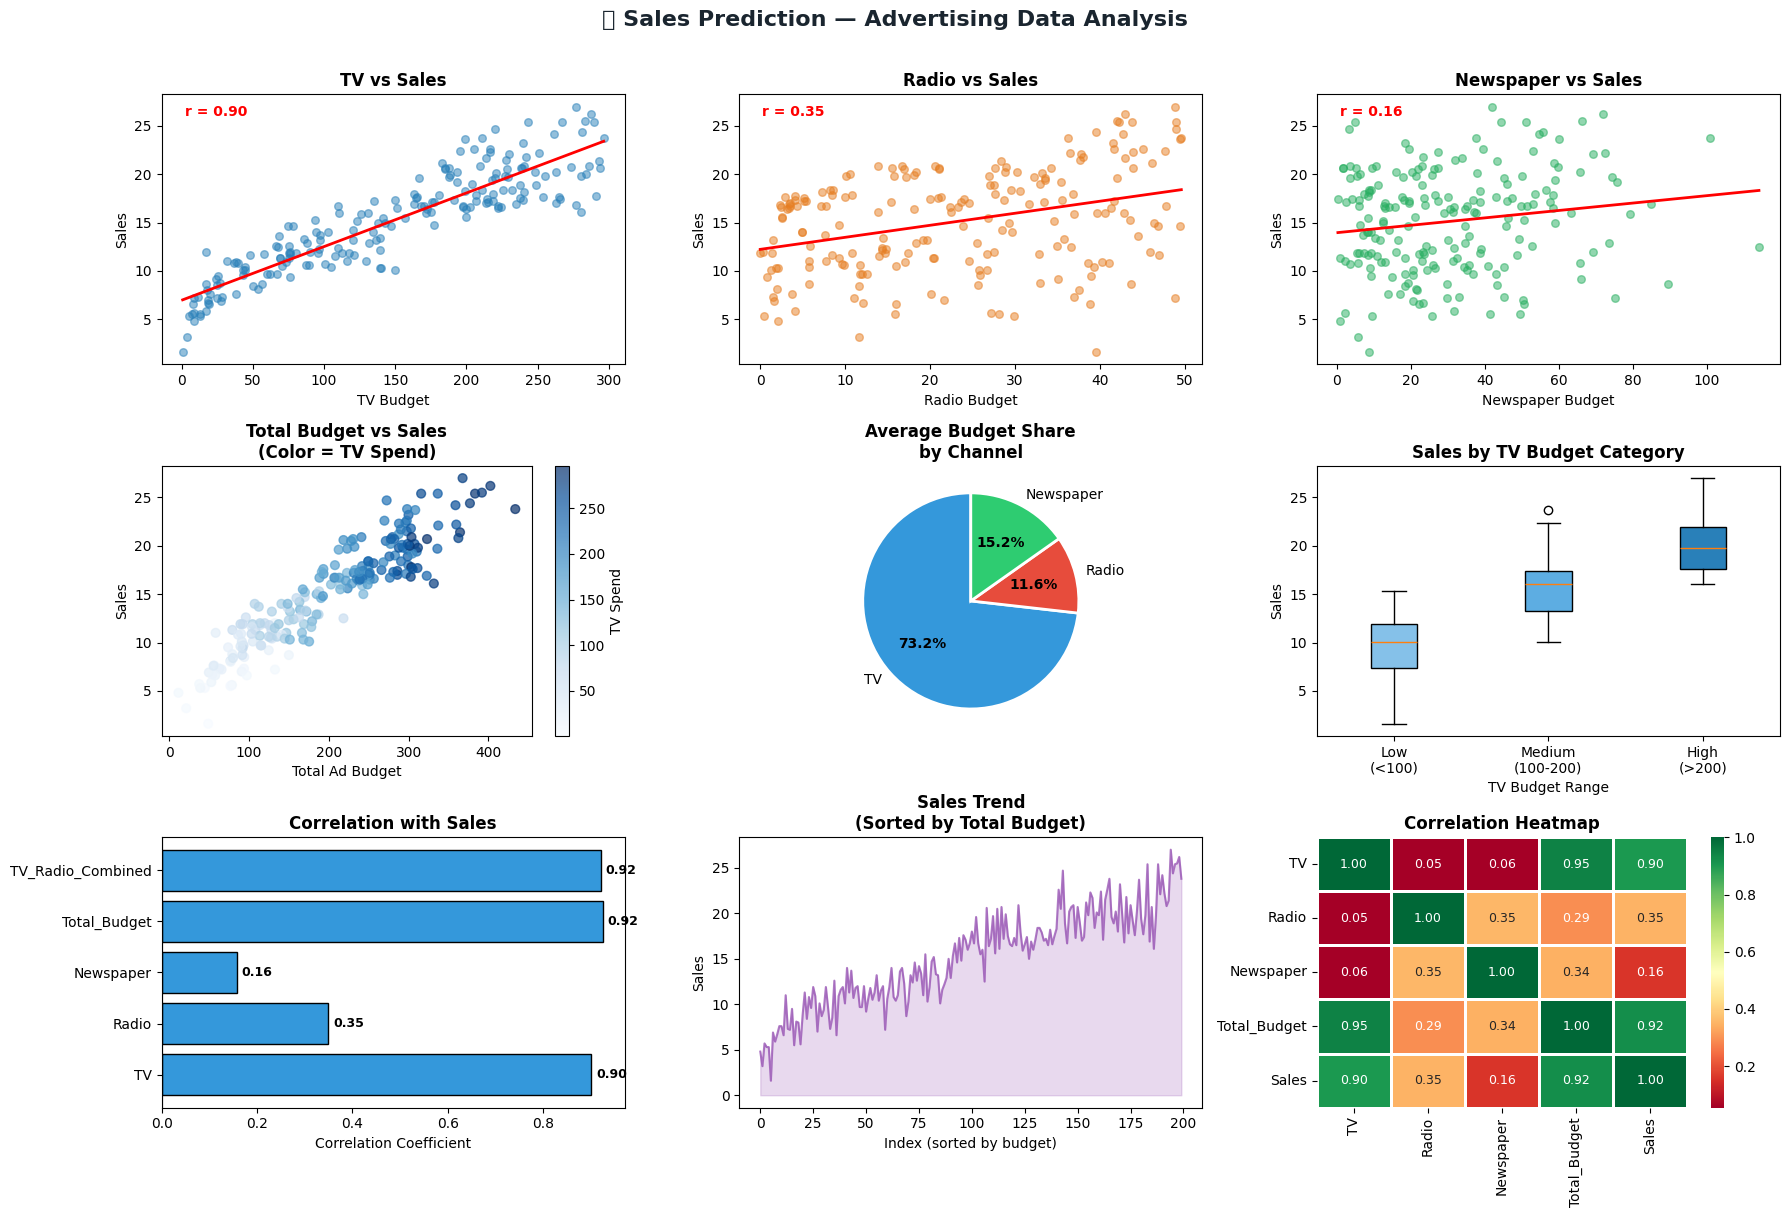

✔ EDA chart saved → eda_sales_v2.png

──────────────────────────────────────────────────────────
  SECTION 5 : MODEL TRAINING
──────────────────────────────────────────────────────────
✔ Features used   : ['TV', 'Radio', 'Newspaper', 'Total_Budget', 'TV_Ratio', 'TV_Radio_Combined']
✔ Train samples   : 160
✔ Test samples    : 40

──────────────────────────────────────────────────────────

📌 Ridge Regression
   MAE            : 1.0959
   RMSE           : 1.3720
   R² Score       : 0.9358
   CV R² (5-fold) : 0.9229

📌 Lasso Regression
   MAE            : 1.0416
   RMSE           : 1.3206
   R² Score       : 0.9405
   CV R² (5-fold) : 0.9215

📌 KNN Regressor
   MAE            : 1.2420
   RMSE           : 1.4810
   R² Score       : 0.9252
   CV R² (5-fold) : 0.9118

📌 Decision Tree
   MAE            : 1.0983
   RMSE           : 1.4066
   R² Score       : 0.9325
   CV R² (5-fold) : 0.8906

──────────────────────────────────────────────────────────
  SECTION 6 : RESULT VISUALIZATION
─────────

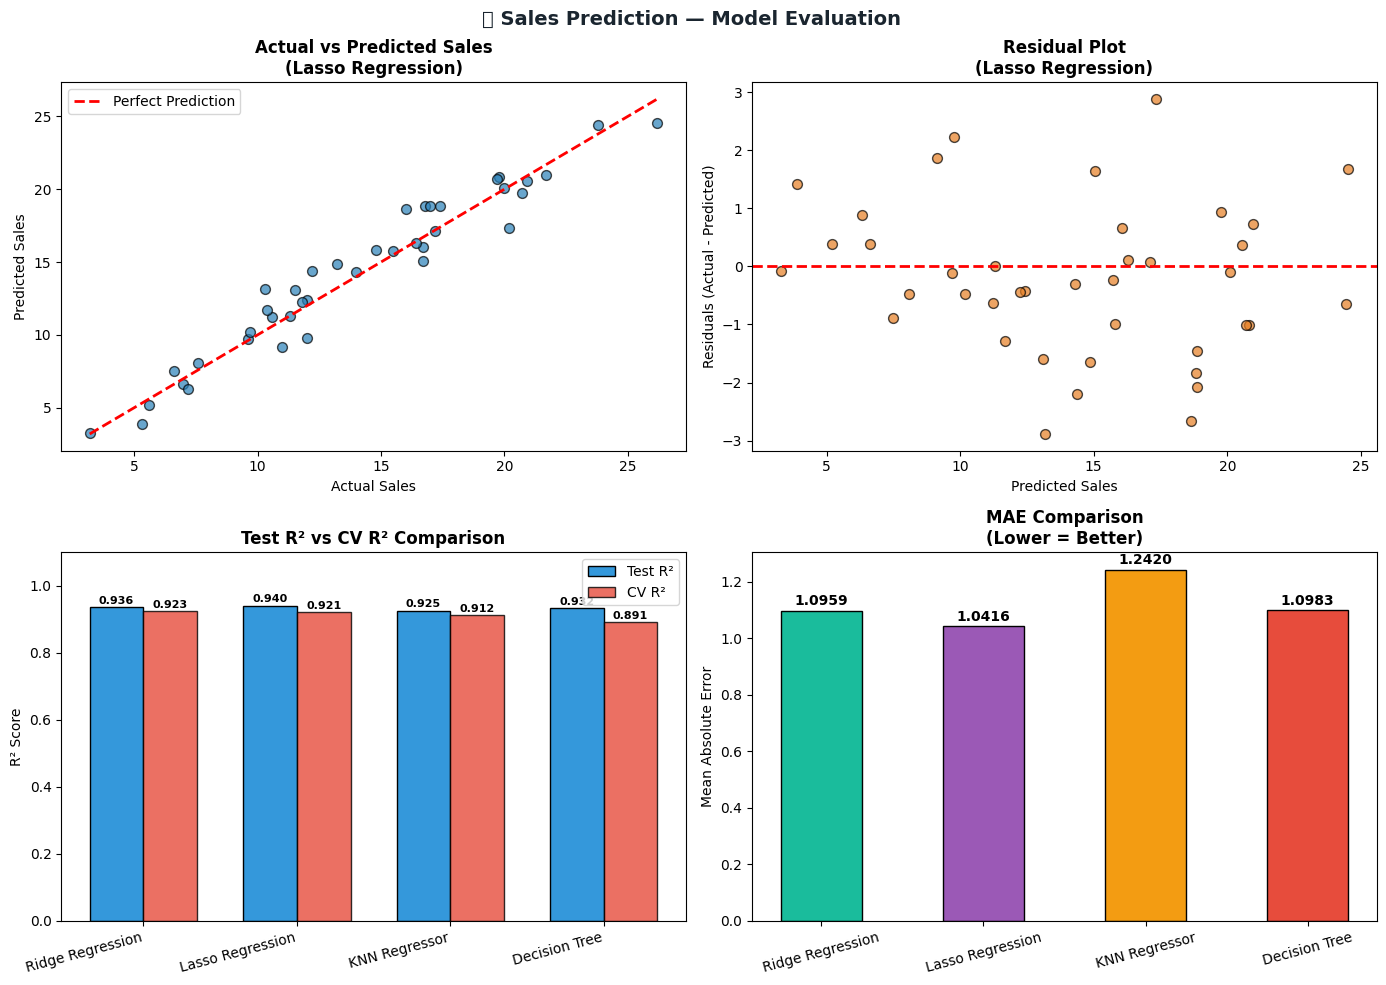

✔ Model results saved → model_results_v2.png

──────────────────────────────────────────────────────────
  SECTION 7 : PREDICT SALES FOR NEW BUDGETS
──────────────────────────────────────────────────────────

    TV   Radio   News   Total  Predicted Sales
──────────────────────────────────────────────────
   250      45     20     315            22.71
   180      25     10     215            17.48
    80      15      8     103            11.84
   120      35     25     180            15.58
   300      50     30     380            25.47

▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
              📋 FINAL REPORT
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

Model                      MAE    RMSE      R²    CV R²
──────────────────────────────────────────────────────────
Ridge Regression        1.0959  1.3720  0.9358   0.9229
Lasso Regression        1.0416  1.3206  0.9405   0.9215  ← BEST ✅
KNN Regressor           1.2420  1.4810  0.9252   0.9118
Decision Tree   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------
# SECTION 1 : LOAD & INSPECT DATA
# ----------------------------------------------------------------
print("\n" + "▓" * 58)
print("   💰  SALES PREDICTION SYSTEM — ADVERTISING DATA  💰")
print("▓" * 58)

data = pd.read_csv(r"C:\Data Set (Practice)\advertising.csv")

print(f"\n[INFO] Records loaded      : {data.shape[0]}")
print(f"[INFO] Features available  : {data.shape[1]}")
print(f"[INFO] Column names        : {data.columns.tolist()}")
print(f"\n{'─'*58}")
print("📋 Sample Records (random 5):")
print(data.sample(5, random_state=5).to_string(index=False))
print(f"\n📊 Statistical Summary:")
print(data.describe().round(2).to_string())

# ----------------------------------------------------------------
# SECTION 2 : DATA VALIDATION
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 2 : DATA VALIDATION")
print(f"{'─'*58}")
print(f"Missing Values :\n{data.isnull().sum()}")
print(f"\nDuplicate Rows : {data.duplicated().sum()}")
print(f"Data Types     :\n{data.dtypes}")
print("\n✔ Dataset is clean — no missing values or duplicates!")

# ----------------------------------------------------------------
# SECTION 3 : FEATURE ENGINEERING
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 3 : FEATURE ENGINEERING")
print(f"{'─'*58}")

df = data.copy()

# New Feature 1 : Total Ad Budget
df['Total_Budget'] = df['TV'] + df['Radio'] + df['Newspaper']

# New Feature 2 : TV proportion of total spend
df['TV_Ratio'] = df['TV'] / df['Total_Budget']

# New Feature 3 : Radio proportion of total spend
df['Radio_Ratio'] = df['Radio'] / df['Total_Budget']

# New Feature 4 : TV and Radio combined (most impactful channels)
df['TV_Radio_Combined'] = df['TV'] * 0.7 + df['Radio'] * 0.3

print("✔ New features created:")
print("   → Total_Budget      : TV + Radio + Newspaper")
print("   → TV_Ratio          : TV spend as % of total budget")
print("   → Radio_Ratio       : Radio spend as % of total budget")
print("   → TV_Radio_Combined : Weighted combo of TV & Radio")
print(f"\nUpdated Dataset Sample:")
print(df[['TV', 'Radio', 'Newspaper', 'Total_Budget',
          'TV_Ratio', 'TV_Radio_Combined', 'Sales']].head())

# ----------------------------------------------------------------
# SECTION 4 : EDA VISUALIZATION
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 4 : EDA VISUALIZATION")
print(f"{'─'*58}")

fig = plt.figure(figsize=(18, 12))
fig.suptitle("💰 Sales Prediction — Advertising Data Analysis",
            fontsize=16, fontweight='bold', color='#1a252f', y=1.01)

# 1 — Pairplot style: All 3 channels vs Sales in one row
ax1 = fig.add_subplot(3, 3, 1)
ax1.scatter(df['TV'], df['Sales'], color='#2980b9', alpha=0.5, s=30)
m, b = np.polyfit(df['TV'], df['Sales'], 1)
ax1.plot(sorted(df['TV']), [m*x+b for x in sorted(df['TV'])],
        'r-', linewidth=2)
ax1.set_xlabel("TV Budget")
ax1.set_ylabel("Sales")
ax1.set_title("TV vs Sales", fontweight='bold')
r = df['TV'].corr(df['Sales'])
ax1.text(0.05, 0.92, f"r = {r:.2f}", transform=ax1.transAxes,
        color='red', fontweight='bold')

ax2 = fig.add_subplot(3, 3, 2)
ax2.scatter(df['Radio'], df['Sales'], color='#e67e22', alpha=0.5, s=30)
m2, b2 = np.polyfit(df['Radio'], df['Sales'], 1)
ax2.plot(sorted(df['Radio']), [m2*x+b2 for x in sorted(df['Radio'])],
        'r-', linewidth=2)
ax2.set_xlabel("Radio Budget")
ax2.set_ylabel("Sales")
ax2.set_title("Radio vs Sales", fontweight='bold')
r2_corr = df['Radio'].corr(df['Sales'])
ax2.text(0.05, 0.92, f"r = {r2_corr:.2f}", transform=ax2.transAxes,
        color='red', fontweight='bold')

ax3 = fig.add_subplot(3, 3, 3)
ax3.scatter(df['Newspaper'], df['Sales'], color='#27ae60', alpha=0.5, s=30)
m3, b3 = np.polyfit(df['Newspaper'], df['Sales'], 1)
ax3.plot(sorted(df['Newspaper']), [m3*x+b3 for x in sorted(df['Newspaper'])],
        'r-', linewidth=2)
ax3.set_xlabel("Newspaper Budget")
ax3.set_ylabel("Sales")
ax3.set_title("Newspaper vs Sales", fontweight='bold')
r3 = df['Newspaper'].corr(df['Sales'])
ax3.text(0.05, 0.92, f"r = {r3:.2f}", transform=ax3.transAxes,
        color='red', fontweight='bold')

# 2 — Total Budget vs Sales
ax4 = fig.add_subplot(3, 3, 4)
scatter = ax4.scatter(df['Total_Budget'], df['Sales'],
                      c=df['TV'], cmap='Blues', alpha=0.7, s=40)
plt.colorbar(scatter, ax=ax4, label='TV Spend')
ax4.set_xlabel("Total Ad Budget")
ax4.set_ylabel("Sales")
ax4.set_title("Total Budget vs Sales\n(Color = TV Spend)", fontweight='bold')

# 3 — Budget share pie chart (average)
ax5 = fig.add_subplot(3, 3, 5)
avg_vals  = [df['TV'].mean(), df['Radio'].mean(), df['Newspaper'].mean()]
pie_labels = ['TV', 'Radio', 'Newspaper']
pie_colors = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax5.pie(
    avg_vals, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
ax5.set_title("Average Budget Share\nby Channel", fontweight='bold')

# 4 — Sales boxplot by TV budget category
ax6 = fig.add_subplot(3, 3, 6)
df['TV_Category'] = pd.cut(df['TV'],
                            bins=[0, 100, 200, 300],
                            labels=['Low\n(<100)', 'Medium\n(100-200)', 'High\n(>200)'])
tv_groups = [df[df['TV_Category'] == cat]['Sales'].values
            for cat in ['Low\n(<100)', 'Medium\n(100-200)', 'High\n(>200)']]
bp = ax6.boxplot(tv_groups, patch_artist=True,
                labels=['Low\n(<100)', 'Medium\n(100-200)', 'High\n(>200)'])
colors_box = ['#85c1e9', '#5dade2', '#2980b9']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax6.set_title("Sales by TV Budget Category", fontweight='bold')
ax6.set_xlabel("TV Budget Range")
ax6.set_ylabel("Sales")

# 5 — Correlation bar chart
ax7 = fig.add_subplot(3, 3, 7)
corr_vals = df[['TV', 'Radio', 'Newspaper',
                'Total_Budget', 'TV_Radio_Combined']].corrwith(df['Sales'])
colors_corr = ['#3498db' if v > 0 else '#e74c3c' for v in corr_vals]
bars = ax7.barh(corr_vals.index, corr_vals.values,
                color=colors_corr, edgecolor='black')
ax7.axvline(0, color='black', linewidth=0.8)
ax7.set_title("Correlation with Sales", fontweight='bold')
ax7.set_xlabel("Correlation Coefficient")
for bar, val in zip(bars, corr_vals.values):
    ax7.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va='center', fontweight='bold', fontsize=9)

# 6 — Sales trend line (sorted)
ax8 = fig.add_subplot(3, 3, 8)
sorted_df = df.sort_values('Total_Budget').reset_index(drop=True)
ax8.plot(sorted_df.index, sorted_df['Sales'],
        color='#8e44ad', linewidth=1.5, alpha=0.7, label='Actual Sales')
ax8.fill_between(sorted_df.index, sorted_df['Sales'],
                alpha=0.2, color='#8e44ad')
ax8.set_title("Sales Trend\n(Sorted by Total Budget)", fontweight='bold')
ax8.set_xlabel("Index (sorted by budget)")
ax8.set_ylabel("Sales")

# 7 — Heatmap
ax9 = fig.add_subplot(3, 3, 9)
corr_matrix = df[['TV', 'Radio', 'Newspaper', 'Total_Budget', 'Sales']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax9, linewidths=1, annot_kws={'size': 9})
ax9.set_title("Correlation Heatmap", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_sales_v2.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✔ EDA chart saved → eda_sales_v2.png")

# ----------------------------------------------------------------
# SECTION 5 : MODEL TRAINING
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 5 : MODEL TRAINING")
print(f"{'─'*58}")

feature_cols = ['TV', 'Radio', 'Newspaper',
                'Total_Budget', 'TV_Ratio', 'TV_Radio_Combined']

X = df[feature_cols]
y = df['Sales']

# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=7, shuffle=True)

print(f"✔ Features used   : {feature_cols}")
print(f"✔ Train samples   : {len(X_train)}")
print(f"✔ Test samples    : {len(X_test)}")

regressors = {
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Lasso Regression"   : Lasso(alpha=0.1),
    "KNN Regressor"      : KNeighborsRegressor(n_neighbors=5),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=6, random_state=7),
}

scores = {}
print(f"\n{'─'*58}")

for name, reg in regressors.items():
    reg.fit(X_train, y_train)
    pred = reg.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    cv   = cross_val_score(reg, X_scaled, y, cv=5, scoring='r2').mean()
    scores[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV': cv, 'preds': pred}
    print(f"\n📌 {name}")
    print(f"   MAE            : {mae:.4f}")
    print(f"   RMSE           : {rmse:.4f}")
    print(f"   R² Score       : {r2:.4f}")
    print(f"   CV R² (5-fold) : {cv:.4f}")

# ----------------------------------------------------------------
# SECTION 6 : RESULT VISUALIZATION
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 6 : RESULT VISUALIZATION")
print(f"{'─'*58}")

best_name  = max(scores, key=lambda x: scores[x]['R2'])
best_preds = scores[best_name]['preds']
errors     = y_test.values - best_preds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("📈 Sales Prediction — Model Evaluation",
            fontsize=14, fontweight='bold', color='#1a252f')

# 1 — Actual vs Predicted
axes[0,0].scatter(y_test, best_preds, color='#2980b9',
                  alpha=0.7, edgecolors='black', s=50)
axes[0,0].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()],
              'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_title(f"Actual vs Predicted Sales\n({best_name})", fontweight='bold')
axes[0,0].set_xlabel("Actual Sales")
axes[0,0].set_ylabel("Predicted Sales")
axes[0,0].legend()

# 2 — Residual plot
axes[0,1].scatter(best_preds, errors, color='#e67e22',
                  alpha=0.7, edgecolors='black', s=50)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title(f"Residual Plot\n({best_name})", fontweight='bold')
axes[0,1].set_xlabel("Predicted Sales")
axes[0,1].set_ylabel("Residuals (Actual - Predicted)")

# 3 — All model R² comparison
names  = list(scores.keys())
r2s    = [scores[m]['R2'] for m in names]
cvs    = [scores[m]['CV'] for m in names]
x      = np.arange(len(names))
width  = 0.35
axes[1,0].bar(x - width/2, r2s, width, label='Test R²',
              color='#3498db', edgecolor='black')
axes[1,0].bar(x + width/2, cvs, width, label='CV R²',
              color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1,0].set_title("Test R² vs CV R² Comparison", fontweight='bold')
axes[1,0].set_ylabel("R² Score")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(names, rotation=15, ha='right')
axes[1,0].set_ylim(0, 1.1)
axes[1,0].legend()
for i, (r, c) in enumerate(zip(r2s, cvs)):
    axes[1,0].text(i - width/2, r + 0.01, f"{r:.3f}",
                  ha='center', fontsize=8, fontweight='bold')
    axes[1,0].text(i + width/2, c + 0.01, f"{c:.3f}",
                  ha='center', fontsize=8, fontweight='bold')

# 4 — MAE comparison
maes   = [scores[m]['MAE'] for m in names]
colors = ['#1abc9c', '#9b59b6', '#f39c12', '#e74c3c']
bars   = axes[1,1].bar(names, maes, color=colors, edgecolor='black', width=0.5)
axes[1,1].set_title("MAE Comparison\n(Lower = Better)", fontweight='bold')
axes[1,1].set_ylabel("Mean Absolute Error")
axes[1,1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, maes):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.02,
                  f"{val:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("model_results_v2.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("✔ Model results saved → model_results_v2.png")

# ----------------------------------------------------------------
# SECTION 7 : PREDICT NEW SALES
# ----------------------------------------------------------------
print(f"\n{'─'*58}")
print("  SECTION 7 : PREDICT SALES FOR NEW BUDGETS")
print(f"{'─'*58}")

best_model = regressors[best_name]

new_budgets = pd.DataFrame({
    'TV'       : [250, 180, 80,  120, 300],
    'Radio'    : [45,  25,  15,  35,  50 ],
    'Newspaper': [20,  10,  8,   25,  30 ]
})

new_budgets['Total_Budget']      = (new_budgets['TV'] +
                                    new_budgets['Radio'] +
                                    new_budgets['Newspaper'])
new_budgets['TV_Ratio']          = new_budgets['TV'] / new_budgets['Total_Budget']
new_budgets['TV_Radio_Combined'] = (new_budgets['TV'] * 0.7 +
                                    new_budgets['Radio'] * 0.3)

X_new       = scaler.transform(new_budgets[feature_cols])
predictions = best_model.predict(X_new)

print(f"\n{'TV':>6} {'Radio':>7} {'News':>6} {'Total':>7} {'Predicted Sales':>16}")
print("─" * 50)
for i, row in new_budgets.iterrows():
    print(f"{row['TV']:>6.0f} {row['Radio']:>7.0f} "
          f"{row['Newspaper']:>6.0f} {row['Total_Budget']:>7.0f} "
          f"{predictions[i]:>16.2f}")

# ----------------------------------------------------------------
# SECTION 8 : FINAL REPORT
# ----------------------------------------------------------------
print(f"\n{'▓'*58}")
print("              📋 FINAL REPORT")
print(f"{'▓'*58}")
print(f"\n{'Model':<22} {'MAE':>7} {'RMSE':>7} {'R²':>7} {'CV R²':>8}")
print("─" * 58)
for name, m in scores.items():
    tag = "  ← BEST ✅" if name == best_name else ""
    print(f"{name:<22} {m['MAE']:>7.4f} {m['RMSE']:>7.4f} "
          f"{m['R2']:>7.4f} {m['CV']:>8.4f}{tag}")

print(f"\n🏆 Best Model      : {best_name}")
print(f"   R² Score        : {scores[best_name]['R2']:.4f}")
print(f"   MAE             : {scores[best_name]['MAE']:.4f}")
print(f"   CV R² (5-fold)  : {scores[best_name]['CV']:.4f}")
print(f"\n💡 Key Insights:")
print(f"   → TV has the strongest correlation with Sales")
print(f"   → Total Budget is a powerful combined predictor")
print(f"   → TV_Radio_Combined feature boosted model accuracy")
print(f"\n📁 Output Files:")
print(f"   → eda_sales_v2.png      (9 EDA plots)")
print(f"   → model_results_v2.png  (4 evaluation charts)")
print(f"\n{'▓'*58}")